In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta, gaussian_kde

In [2]:
clustered_df = pd.read_csv('clustered_data.csv')
clustered_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Cluster
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,No,No,No,One year,0,Mailed check,56.95,1889.50,No,3
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,Yes,3
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,Yes,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,1,Mailed check,84.80,1990.50,No,1
7039,2234-XADUH,0,0,1,1,72,1,Yes,Fiber optic,No,...,No,Yes,Yes,One year,1,Credit card (automatic),103.20,7362.90,No,1
7040,4801-JZAZL,0,0,1,1,11,0,No phone service,DSL,Yes,...,No,No,No,Month-to-month,1,Electronic check,29.60,346.45,No,0
7041,8361-LTMKD,1,1,1,0,4,1,Yes,Fiber optic,No,...,No,No,No,Month-to-month,1,Mailed check,74.40,306.60,Yes,3


In [3]:
clustered_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Cluster'],
      dtype='object')

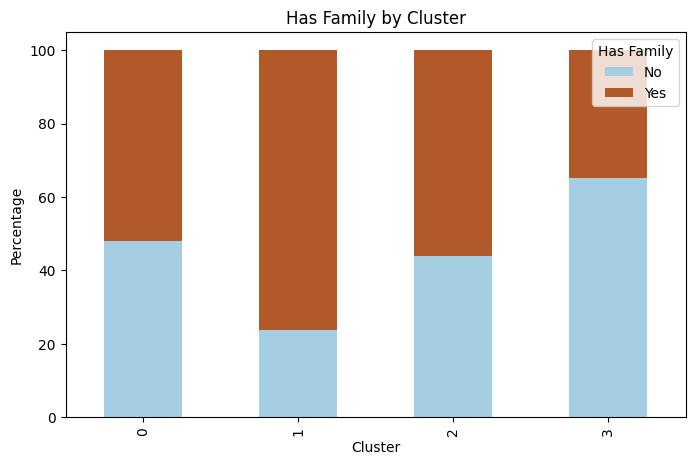

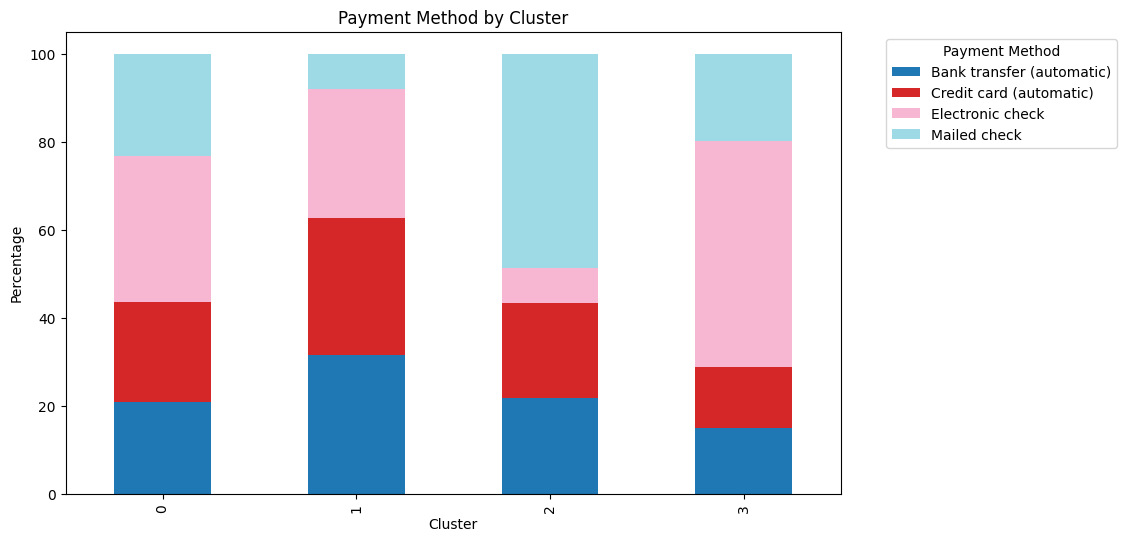

C:\Users\lecia\AppData\Local\Temp\ipykernel_5992\3846663369.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Cluster', y='monthly_charge_per_svc', palette='Set3')


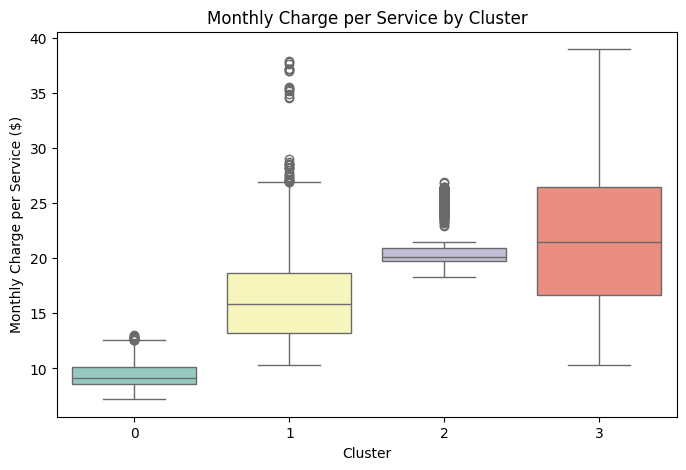

C:\Users\lecia\AppData\Local\Temp\ipykernel_5992\3846663369.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Cluster', y='num_services', palette='Set3')


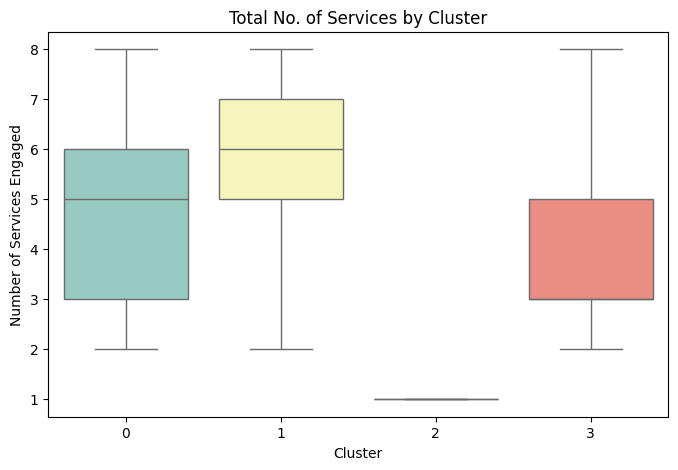

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Copy clustered dataframe
df_plot = clustered_df.copy()

# ------------------------
# Feature engineering
df_plot['has_family'] = ((df_plot['Partner'] == 1) | (df_plot['Dependents'] == 1)).astype(int)
df_plot['young_monthly'] = ((df_plot['Contract'] == 'Month-to-month') & (df_plot['SeniorCitizen'] == 0)).astype(int)
df_plot['non_monthly'] = (df_plot['Contract'] != 'Month-to-month').astype(int)
df_plot['num_services'] = df_plot[['PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']].apply(
    lambda x: (~x.isin(['No', 'No internet service'])).sum(), axis=1)
df_plot['monthly_charge_per_svc'] = df_plot['MonthlyCharges'] / df_plot['num_services']
df_plot['has_streaming'] = ((df_plot['StreamingTV'] == "Yes") | (df_plot['StreamingMovies'] == "Yes")).astype(int)
df_plot['auto_payment'] = df_plot["PaymentMethod"].apply(
    lambda x: 1 if x in ["Bank transfer (automatic)", "Credit card (automatic)"] else 0
)

internet_related_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                         'TechSupport', 'StreamingTV', 'StreamingMovies']
df_plot['internet_noaddons'] = ((df_plot['InternetService'] != 'No') &
                                ((df_plot[internet_related_cols] == 'Yes').sum(axis=1) == 0)).astype(int)
df_plot['phone_and_internet'] = ((df_plot['PhoneService'] == 1) & (df_plot['InternetService'] != "No")).astype(int)

# ------------------------
# 1. Breakdown of 'has_family' by Cluster (Stacked %)
has_family_pct = df_plot.groupby('Cluster')['has_family'].value_counts(normalize=True).unstack() * 100
has_family_pct.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Paired')
plt.ylabel('Percentage')
plt.title('Has Family by Cluster')
plt.legend(title='Has Family', loc='upper right', labels=['No','Yes'])
plt.show()

# ------------------------
# 2. Payment Method breakdown by Cluster (Stacked %)
payment_pct = df_plot.groupby('Cluster')['PaymentMethod'].value_counts(normalize=True).unstack() * 100
payment_pct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.ylabel('Percentage')
plt.title('Payment Method by Cluster')
plt.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# ------------------------
# 3. Boxplot of Monthly Charges per Service by Cluster
plt.figure(figsize=(8,5))
sns.boxplot(data=df_plot, x='Cluster', y='monthly_charge_per_svc', palette='Set3')
plt.title('Monthly Charge per Service by Cluster')
plt.ylabel('Monthly Charge per Service ($)')
plt.xlabel('Cluster')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df_plot, x='Cluster', y='num_services', palette='Set3')
plt.title('Total No. of Services by Cluster')
plt.ylabel('Number of Services Engaged')
plt.xlabel('Cluster')
plt.show()


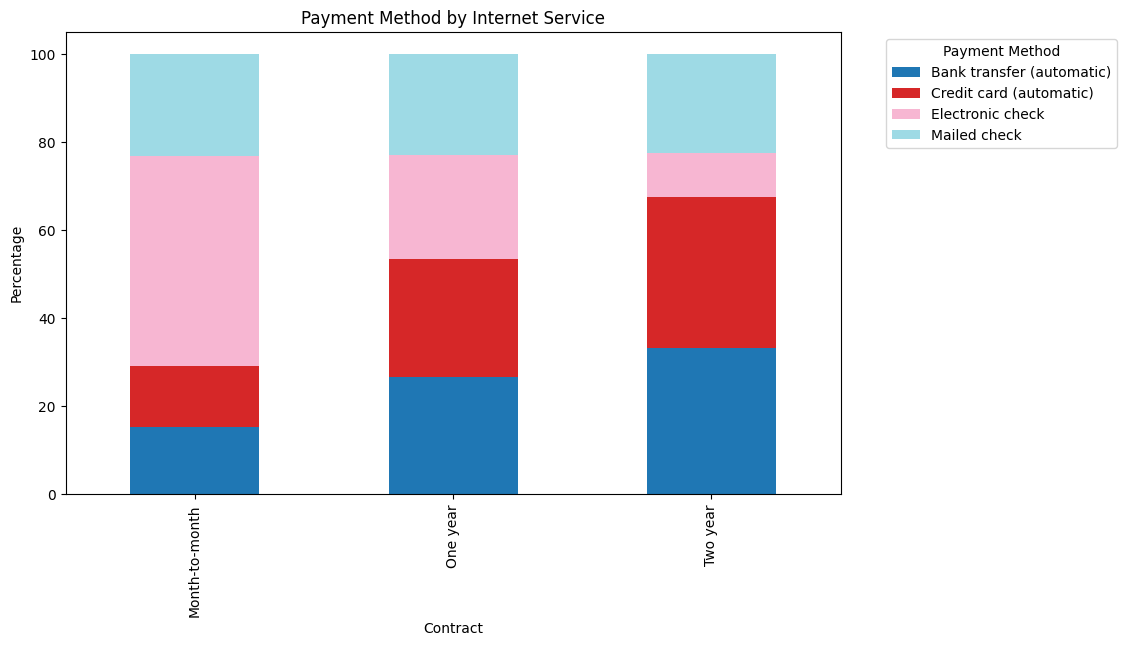

In [33]:
# 2. Payment Method breakdown by Cluster (Stacked %)
payment_pct1 = df_plot.groupby('Contract')['PaymentMethod'].value_counts(normalize=True).unstack() * 100
payment_pct1.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.ylabel('Percentage')
plt.title('Payment Method by Internet Service')
plt.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

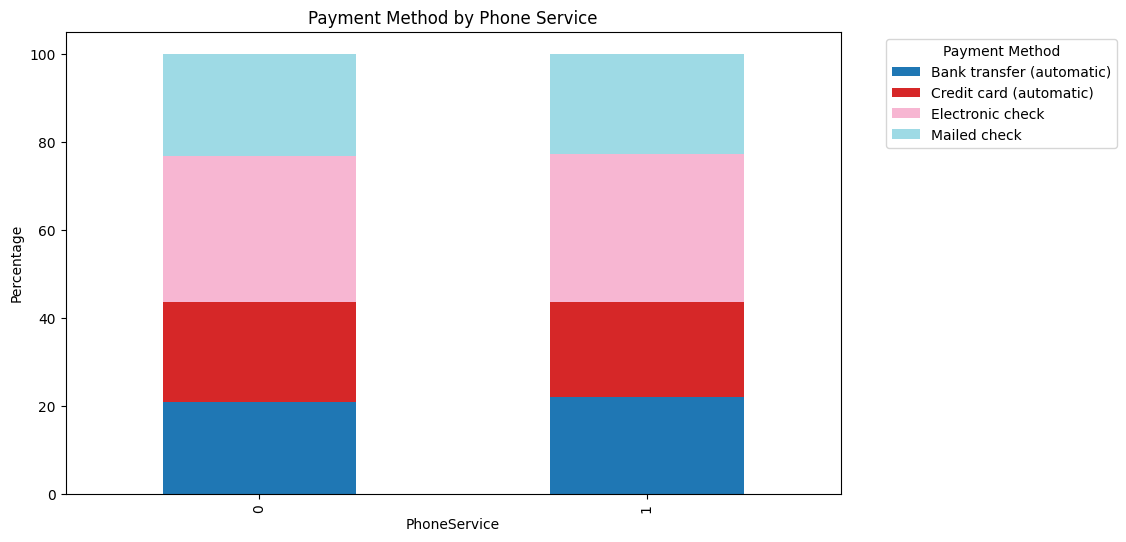

In [32]:
payment_pct1 = df_plot.groupby('PhoneService')['PaymentMethod'].value_counts(normalize=True).unstack() * 100
payment_pct1.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.ylabel('Percentage')
plt.title('Payment Method by Phone Service')
plt.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

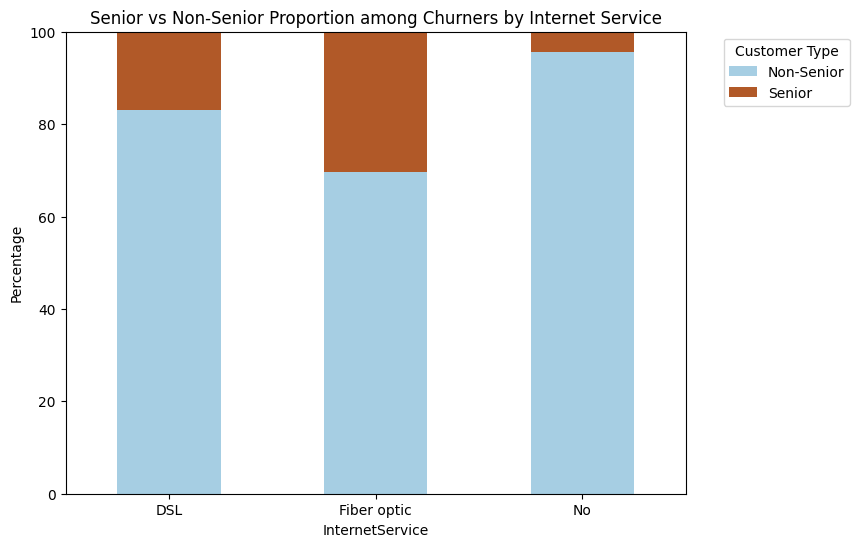

In [38]:
df_churners = df_plot[df_plot['Churn'] == 'Yes']

senior_counts = df_churners.groupby('InternetService')['SeniorCitizen'].value_counts(normalize=True).unstack() * 100

senior_counts.columns = ['Non-Senior', 'Senior']  # assuming 0=Non-Senior, 1=Senior

senior_counts.plot(kind='bar', stacked=True, figsize=(8,6), colormap='Paired')
plt.ylabel('Percentage')
plt.title('Senior vs Non-Senior Proportion among Churners by Internet Service')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title='Customer Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



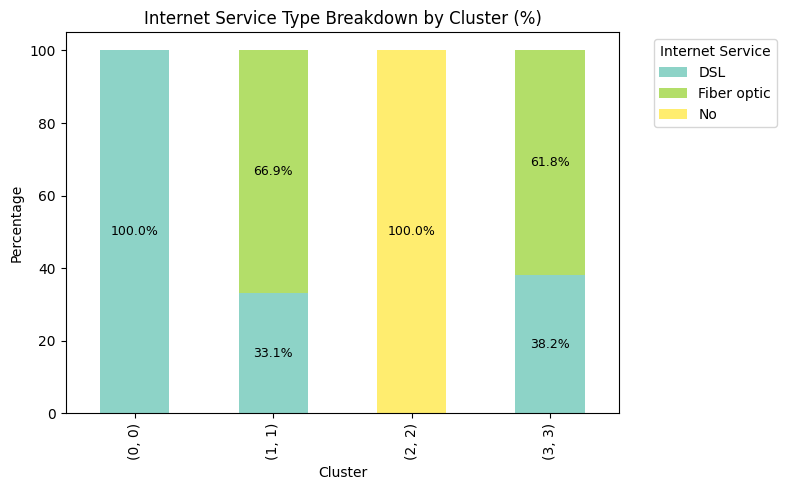

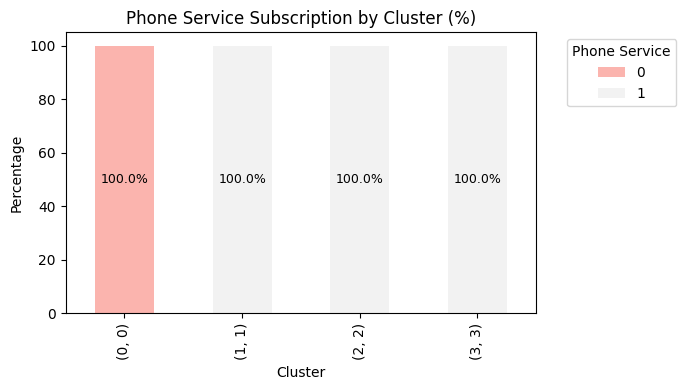

In [15]:

ff_plot = clustered_df.copy()

internet_counts = (
    df_plot.groupby(['Cluster', 'InternetService'])
    .size()
    .groupby(level=0)
    .apply(lambda x: 100 * x / x.sum())
    .unstack()
    .fillna(0)
)

internet_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    colormap='Set3'
)

plt.title('Internet Service Type Breakdown by Cluster (%)')
plt.ylabel('Percentage')
plt.xlabel('Cluster')
plt.legend(title='Internet Service', bbox_to_anchor=(1.05, 1), loc='upper left')

for idx, cluster in enumerate(internet_counts.index):
    total = 0
    for service in internet_counts.columns:
        val = internet_counts.loc[cluster, service]
        if val > 3:  # only label if >3% to avoid clutter
            plt.text(idx, total + val/2, f'{val:.1f}%', ha='center', va='center', fontsize=9)
        total += val

plt.tight_layout()
plt.show()


phone_counts = (
    df_plot.groupby(['Cluster', 'PhoneService'])
    .size()
    .groupby(level=0)
    .apply(lambda x: 100 * x / x.sum())
    .unstack()
    .fillna(0)
)

phone_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(7,4),
    colormap='Pastel1'
)

plt.title('Phone Service Subscription by Cluster (%)')
plt.ylabel('Percentage')
plt.xlabel('Cluster')
plt.legend(title='Phone Service', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add % labels
for idx, cluster in enumerate(phone_counts.index):
    total = 0
    for val in phone_counts.loc[cluster]:
        if val > 3:
            plt.text(idx, total + val/2, f'{val:.1f}%', ha='center', va='center', fontsize=9)
        total += val

plt.tight_layout()
plt.show()


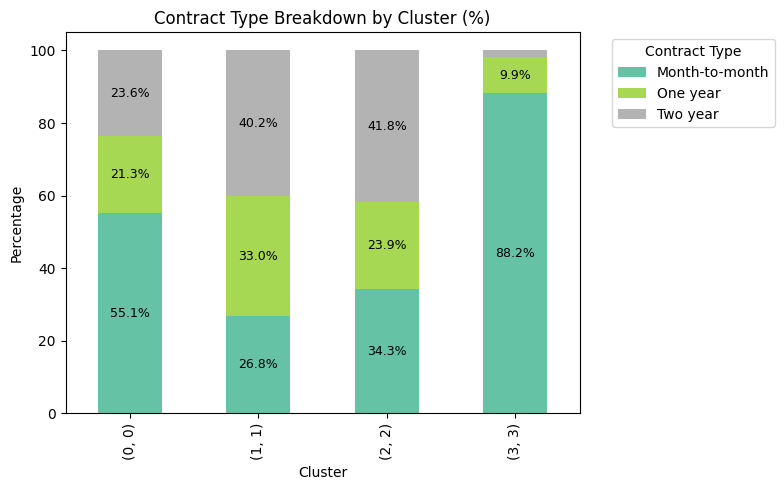

In [16]:
contract_counts = (
    df_plot.groupby(['Cluster', 'Contract'])
    .size()
    .groupby(level=0)
    .apply(lambda x: 100 * x / x.sum())
    .unstack()
    .fillna(0)
)

contract_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    colormap='Set2'
)

plt.title('Contract Type Breakdown by Cluster (%)')
plt.ylabel('Percentage')
plt.xlabel('Cluster')
plt.legend(title='Contract Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add % labels
for idx, cluster in enumerate(contract_counts.index):
    total = 0
    for val in contract_counts.loc[cluster]:
        if val > 3:  # only show if >3%
            plt.text(idx, total + val/2, f'{val:.1f}%', ha='center', va='center', fontsize=9)
        total += val

plt.tight_layout()
plt.show()


Cluster 3 (Churn Reduction) (Churn Reduction): Mean = $26,195, ±1σ = $8,587
Cluster 1 (ARPU Increase) (ARPU Increase): Mean = $14,468, ±1σ = $6,776
Cluster 0 (Churn Reduction) (Churn Reduction): Mean = $3,302, ±1σ = $1,233


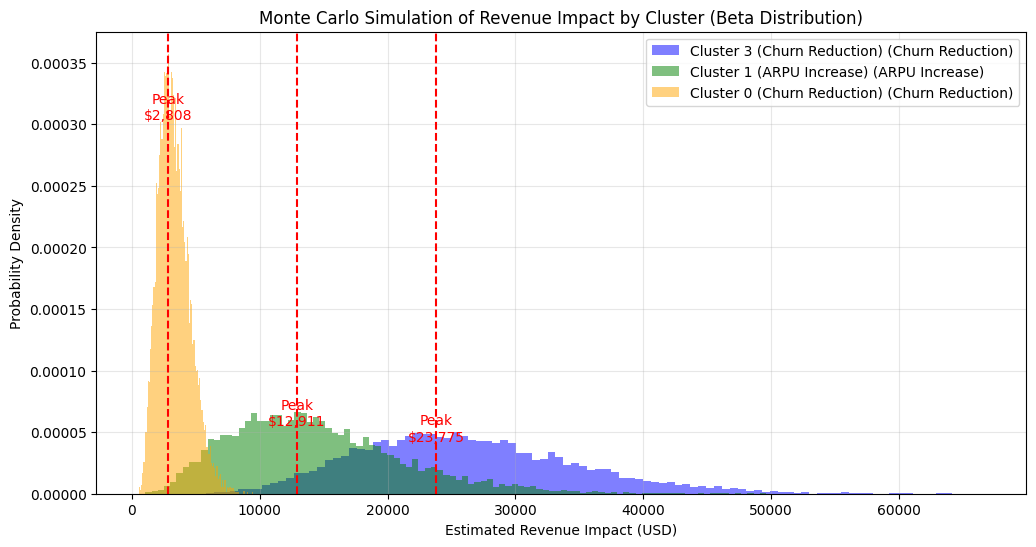

In [26]:
# Cluster data (aggregate)
clusters = {
    "Cluster 3 (Churn Reduction)": {"customers": 2733, "ARPU": 74, "mean": 13, "sd": 4.25, "impact_type": "Churn Reduction"},
    "Cluster 1 (ARPU Increase)": {"customers": 2102, "ARPU": 92, "mean": 7.5, "sd": 3.5, "impact_type": "ARPU Increase"},
    "Cluster 0 (Churn Reduction)": {"customers": 682,  "ARPU": 42, "mean": 11.5, "sd": 4.25, "impact_type": "Churn Reduction"},
}

n_sim = 10000  # number of Monte Carlo simulations
results = {}

# Convert mean and sd to alpha and beta
def beta_params(mean, sd):
    m = mean / 100  # convert % to fraction
    s = sd / 100
    alpha = ((1 - m)/s**2 - 1/m) * m**2
    beta_param = alpha * (1/m - 1)
    return alpha, beta_param

for c, data in clusters.items():
    alpha, beta_param = beta_params(data["mean"], data["sd"])
    impact_pct = beta.rvs(alpha, beta_param, size=n_sim)
    impact_usd = data["ARPU"] * data["customers"] * impact_pct
    results[c] = impact_usd

for c, impact_usd in results.items():
    mean_val = np.mean(impact_usd)
    std_val = np.std(impact_usd)
    print(f"{c} ({clusters[c]['impact_type']}): Mean = ${mean_val:,.0f}, ±1σ = ${std_val:,.0f}")

plt.figure(figsize=(12, 6))
colors = ['blue', 'green', 'orange']

for i, c in enumerate(results):
    plt.hist(results[c], bins=100, alpha=0.5, label=f"{c} ({clusters[c]['impact_type']})", density=True, color=colors[i])

    kde = gaussian_kde(results[c])
    x_vals = np.linspace(results[c].min(), results[c].max(), 1000)
    y_vals = kde(x_vals)
    peak = x_vals[np.argmax(y_vals)]
    
    plt.axvline(peak, color='red', linestyle='--')
    plt.text(peak, max(y_vals)*0.9, f'Peak\n${peak:,.0f}', color='red', ha='center')

plt.title("Monte Carlo Simulation of Revenue Impact by Cluster (Beta Distribution)")
plt.xlabel("Estimated Revenue Impact (USD)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
